# Figure 2 — Vector Autoregression (VAR) Summary

Self-contained notebook reproducing panels A, C, D, and E of the VAR summary figure (panel B is a schematic, not reproduced here). All numerics are re-run from the shared `src/` pipeline — nothing is loaded from pre-computed caches.


In [1]:
import os, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

sys.path.insert(0, str(Path.cwd()))

warnings.filterwarnings("ignore", category=RuntimeWarning)

FIGDIR, RESULTS_DIR = "outputs/figures/var", "outputs/results/var"
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGDIR, f"{name}.{ext}"))
    print(f"saved {FIGDIR}/{name}.{{pdf,png}}")


## Panel A — Node activity, edge couplings, and p-SFA reconstruction

In [2]:
from src.sweeps import simulate, evaluate
from src.util import global_zscore, moving_average_centered_any
from src.pearson_edge import build_edges


In [3]:
DEMO = dict(
    # --- generative model -------------------------------------------------
    N=6,                     # number of nodes
    T=10_000,                # number of samples
    Sigma=0.1,               # innovation (observation) noise variance
    tvp_amp=1.0,             # a_TVP: driver amplitude
    tvp_period=2_000,        # P: driver period      -> P/T = 0.5
    tvp_phase_rad=0.0,       # phi
    target_rho0=0.8,         # requested spectral radius of the baseline A0
    alpha=0.9,               # requested modulation strength (pre-scaling)
    rho_max=0.8,             # cap on max_t rho(A_t); realised value is 0.95*rho_max
    A_0_is_zero=False,       # A0 = 0 triggers the d^2 identifiability pathology
    tvp_noise_std=0.0,       # sigma_d: dynamical noise injected into the driver
    # --- C pattern --------------------------------------------------------
    C_entry_dist="uniform",
    C_dist_scale=1.0,
    C_include_diagonal=False,
    C_symmetric=True,
    C_frac=1.0,              # fraction of nodes inside the modulated subnetwork
    # --- p-SFA pipeline -----------------------------------------------------
    windowing_mode="rolling",
    node_win=1,
    edge_win=601,            # W: centred rolling window on the edge features
)

demo_seed = 123

X, d, info = simulate(DEMO, seed=demo_seed)
res = evaluate(X, d, DEMO, features="edges")

# rebuild the intermediate representations for plotting
Z_s   = moving_average_centered_any(global_zscore(X), DEMO["node_win"])
E_raw, pairs = build_edges(Z_s)
E_s   = moving_average_centered_any(E_raw - E_raw.mean(0, keepdims=True), DEMO["edge_win"])

print(f"R2 = {res['R2']:.3f}   r = {res['rP']:.3f}   rho_s = {res['rS']:.3f}")
print(f"realised rho(A0) = {info['rho_A0']:.3f}, max_t rho(A_t) = {info['rho_max_realised']:.3f}")


R2 = 0.954   r = 0.977   rho_s = 0.974
realised rho(A0) = 0.331, max_t rho(A_t) = 0.760


saved outputs/figures/var/panelA_var_demo.{pdf,png}


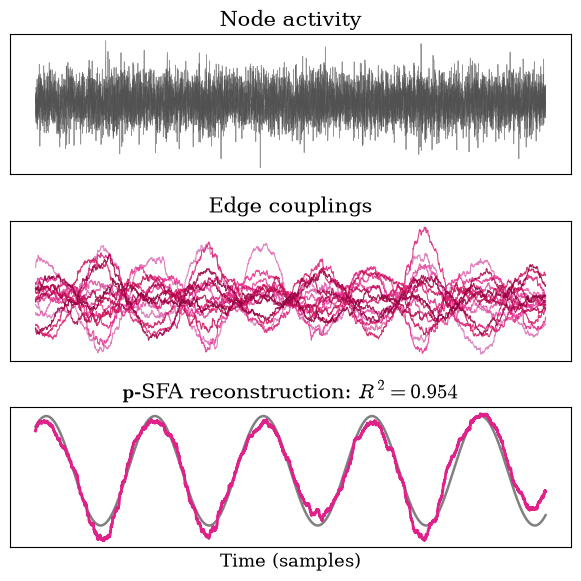

In [4]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

COL = {
    "node":   "#4d4d4d",
    "driver": "#111111",
    "edge":   "#E0218A",
}

fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=False)

# (i) node activity
t = np.arange(len(Z_s))
for i in range(min(DEMO["N"], 4)):
    axes[0].plot(t[::5], Z_s[::5, i], lw=0.6, alpha=0.6, color=COL["node"])

# (ii) edge time series
te = np.arange(len(E_s))
pinks = plt.cm.PuRd(np.linspace(0.45, 0.9, E_s.shape[1]))
for k in range(E_s.shape[1]):
    axes[1].plot(te[::5], E_s[::5, k], lw=0.8, alpha=0.85, color=pinks[k])

# (iii) recovery
td = np.arange(len(res["d_aligned"]))
axes[2].plot(td, res["d_aligned"], color='#808080', lw=1.8)
axes[2].plot(td, res["y_fit"], color=COL["edge"], lw=2.0)

titles = [
    "Node activity",
    "Edge couplings",
    rf"$\bf{{p}}$-SFA reconstruction: $R^2 = {res['R2']:.3f}$",
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=15)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)

axes[2].set_xlabel("Time (samples)", fontsize=13)

fig.tight_layout(pad=1.4)
save(fig, "panelA_var_demo")


## Panels C & D — Variance ↔ coupling mixing sweep

Source: `VAR_new_mechanism.ipynb`. The mixing path is `alpha(ξ) = alpha_max * ξ`, `gamma(ξ) = gamma_max * (1 - ξ)`: ξ=0 is gain/variance-only, ξ=1 is coupling-only.

In [5]:
from src.gain import GAIN_CFG, FEATURES_3, run_mechanism_mixture_sweep


In [6]:
XIS = np.linspace(0, 1, 21)

df_mix = run_mechanism_mixture_sweep(
    xis=XIS,
    alpha_max=GAIN_CFG["alpha"], gamma_max=0.1,
    seeds=range(8), cfg=GAIN_CFG, names=FEATURES_3,
    cache="mechanism_mixture_sweep.csv",
)


[cache] loading /Users/ritviksharma/Projects/final_psfa_code/outputs/results/var/mechanism_mixture_sweep.csv


saved outputs/figures/var/panelC_mixture_bar.{pdf,png}


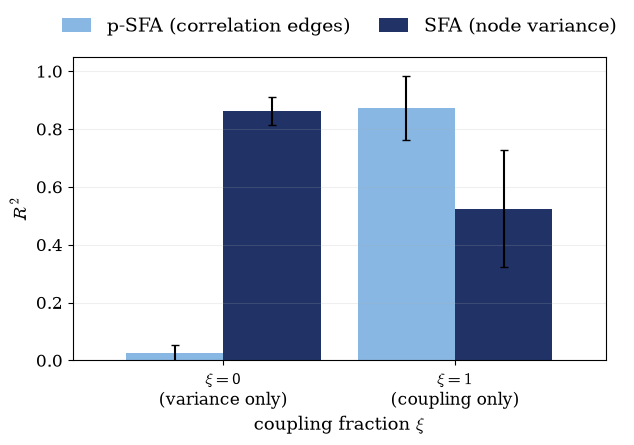

In [7]:
FEATURES_2 = ["edges-corr", "node-var"]

COL = {"edges-cov": "#2a6f72", "edges-corr": "#7bb0e2", "node-var": "#071c55"}
LAB = {"edges-cov": "p-SFA (covariance edges)", "edges-corr": "p-SFA (correlation edges)",
       "node-var": "SFA (node variance)"}

# --- Panel C: bar plot at the xi=0 / xi=1 endpoints ---------------------
order_xi = [0.0, 1.0]
xs = np.arange(len(order_xi))
w = 0.42

fig, ax = plt.subplots(figsize=(6.2, 4.4))

for k, f in enumerate(FEATURES_2):
    mu = [df_mix.loc[df_mix["xi"] == xi, f"R2_{f}"].mean() for xi in order_xi]
    sd = [df_mix.loc[df_mix["xi"] == xi, f"R2_{f}"].std() for xi in order_xi]
    ax.bar(xs + (k - 0.5) * w, mu, w, yerr=sd, capsize=3,
           color=COL[f], label=LAB[f], alpha=0.9)

ax.set_xticks(xs)
ax.set_xticklabels(
    [r"$\xi=0$" + "\n(variance only)", r"$\xi=1$" + "\n(coupling only)"],
    fontsize=8
)
ax.set_xlabel(r"coupling fraction $\xi$", fontsize=13)
ax.set_ylabel(r"$R^2$", fontsize=13)
ax.tick_params(axis="both", labelsize=12)
ax.set_ylim(0, 1.05)
ax.set_xlim(-0.65, 1.65)
ax.grid(axis="y", alpha=0.2)

ax.legend(frameon=False, fontsize=14, loc="lower center",
          bbox_to_anchor=(0.5, 1.01), ncol=2, columnspacing=1.5, handlelength=1.5)

fig.subplots_adjust(left=0.13, right=0.99, bottom=0.18, top=0.87)

save(fig, "panelC_mixture_bar")


saved outputs/figures/var/panelD_mixture_recovery.{pdf,png}


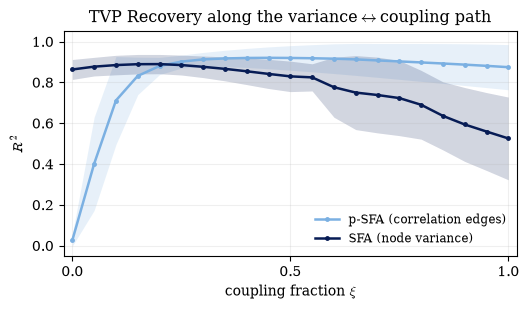

In [8]:
# --- Panel D: R^2 recovery along the full xi path ------------------------
fig, ax = plt.subplots(figsize=(5.4, 3.2))

for f in FEATURES_2:
    g = df_mix.groupby("xi")[f"R2_{f}"]
    mu, sd = g.mean(), g.std()
    ax.plot(mu.index, mu.values, "-o", ms=2.5, color=COL[f], label=LAB[f], lw=1.8)
    ax.fill_between(mu.index, mu - sd, mu + sd, color=COL[f], alpha=0.18, lw=0)

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel(r"coupling fraction $\xi$", fontsize=10)
ax.set_ylabel(r"$R^2$", fontsize=10)
ax.set_xticks([0, 0.5, 1.0])
ax.grid(True, alpha=0.2)

ax.legend(frameon=False, loc="lower right", fontsize=8.5)
ax.set_title("TVP Recovery along the variance$\\leftrightarrow$coupling path",
             loc="center", fontsize=11.5)

fig.tight_layout()
save(fig, "panelD_mixture_recovery")


## Panel E — Recovery sweeps

Source: `var_figures.ipynb`. Four independent sweeps (spectral radius, modulation strength, driver period, driver noise), each over 10 seeds; the spectral-radius panel additionally shows a driver-free null (95th percentile over 20 reps per point).

In [9]:
from copy import deepcopy
from src.sweeps import CANON, cfg_with, run_sweep_features, summarise, lock_window_to_period
from src.util import make_driver, moving_average_centered_any
from src.features import edges_corr_local
from src.sfa import affine_align, r2_score
from sksfa import SFA


In [10]:
ACTIVE = cfg_with(target_rho0=0.8, edge_win=601)
SEEDS = range(10)
METRIC = "R2_edges-corr"


In [11]:
def null_r2_corr(cfg, n_rep=20, seed=1):
    """Driver-free null on the correlation-edge feature: same dynamics with
    a_TVP = 0 (genuinely stationary), scored against the sinusoid that would
    have been the driver."""
    null_cfg = deepcopy(cfg)
    null_cfg["tvp_amp"] = 0.0
    null_cfg["tvp_noise_std"] = 0.0
    d_ref = make_driver(cfg["T"], cfg["tvp_amp"], cfg["tvp_period"], phase=cfg["tvp_phase_rad"])
    d_ref = moving_average_centered_any(moving_average_centered_any(d_ref, cfg["node_win"]), cfg["edge_win"])
    out = np.empty(n_rep)
    for k in range(n_rep):
        Xk, _, _ = simulate(null_cfg, seed=seed * 1000 + k)
        Xn = moving_average_centered_any(Xk, cfg["node_win"])
        F = edges_corr_local(Xn, cfg["edge_win"])
        m = min(len(d_ref), F.shape[0])
        y = SFA(n_components=5, fill_mode="zero").fit_transform(F[:m])[:, 0]
        y_fit, _, _ = affine_align(y, d_ref[:m])
        out[k] = r2_score(d_ref[:m], y_fit)
    return out


In [12]:
# --- Spectral radius sweep (with driver-free null band) ------------------
rho_vals = [0.05, 0.1, 0.2, 0.3, 0.45, 0.6, 0.75, 0.85, 0.92, 0.97, 0.99]
df_rho = run_sweep_features("rho_max", rho_vals, seeds=SEEDS, base=ACTIVE,
                            names=["edges-corr"])

null_rows = []
for rm in rho_vals:
    cfg_rm = deepcopy(ACTIVE)
    cfg_rm["rho_max"] = rm
    vals = null_r2_corr(cfg_rm, n_rep=20, seed=1)
    null_rows.append(dict(rho_max=rm, null_p95=np.percentile(vals, 95)))
df_null_rho = pd.DataFrame(null_rows)

# --- Modulation strength sweep --------------------------------------------
amp_vals = [0.02, 0.05, 0.1, 0.15, 0.25, 0.4, 0.5, 0.75, 1.0]
df_amp = run_sweep_features("tvp_amp", amp_vals, seeds=SEEDS, base=ACTIVE,
                            names=["edges-corr"])

# --- Driver period sweep (window locked to period/4, log-x axis) ---------
T = ACTIVE["T"]
pt_vals  = [0.02, 0.05, 0.1, 0.15, 0.25, 0.4, 0.5, 0.75, 1.0]
per_vals = [int(p * T) for p in pt_vals]
df_period = run_sweep_features("tvp_period", per_vals, seeds=SEEDS, base=ACTIVE,
                               names=["edges-corr"], derive=lock_window_to_period(4.0))
df_period["P_over_T"] = df_period["tvp_period"] / T

# --- Driver noise sweep ----------------------------------------------------
noise_vals = [0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0, 1.5, 2.0]
df_noise = run_sweep_features("tvp_noise_std", noise_vals, seeds=SEEDS, base=ACTIVE,
                              names=["edges-corr"])


[sweep] rho_max = 0.05   best: edges-corr = 0.028
[sweep] rho_max = 0.1   best: edges-corr = 0.028
[sweep] rho_max = 0.2   best: edges-corr = 0.033
[sweep] rho_max = 0.3   best: edges-corr = 0.078
[sweep] rho_max = 0.45   best: edges-corr = 0.361
[sweep] rho_max = 0.6   best: edges-corr = 0.786
[sweep] rho_max = 0.75   best: edges-corr = 0.893
[sweep] rho_max = 0.85   best: edges-corr = 0.919
[sweep] rho_max = 0.92   best: edges-corr = 0.925
[sweep] rho_max = 0.97   best: edges-corr = 0.923
[sweep] rho_max = 0.99   best: edges-corr = 0.920
[sweep] tvp_amp = 0.02   best: edges-corr = 0.180
[sweep] tvp_amp = 0.05   best: edges-corr = 0.494
[sweep] tvp_amp = 0.1   best: edges-corr = 0.749
[sweep] tvp_amp = 0.15   best: edges-corr = 0.864
[sweep] tvp_amp = 0.25   best: edges-corr = 0.927
[sweep] tvp_amp = 0.4   best: edges-corr = 0.944
[sweep] tvp_amp = 0.5   best: edges-corr = 0.944
[sweep] tvp_amp = 0.75   best: edges-corr = 0.931
[sweep] tvp_amp = 1.0   best: edges-corr = 0.909
[sweep] 

In [13]:
INK    = "#0b0b0b"
MUTED  = "#52514e"
AXIS   = "#c3c2b7"
ACCENT = "#2a78d6"   # mean R^2 line + SD band color
NOISE  = "#898781"   # null-band color

def plot_sweep_gridstyle(df, param, ax, metric=METRIC, title=None, xlabel=None,
                         logx=False, canon_value=None, null=None):
    """Restyled sweep plot: grid on, explicit mean/SD legend entries, bold left-aligned title."""
    s = summarise(df, param, metric)

    if null is not None:
        ax.fill_between(null[param], 0, null["null_p95"], color=NOISE, alpha=0.25, lw=0)
        ax.text(0.98, 0.02, "null (95th pct)", ha="right", va="bottom",
                fontsize=8, color=MUTED, transform=ax.transAxes)

    ax.plot(s[param], s["mean"], "-o", ms=3.5, color=ACCENT, label=r"mean $R^2$")
    ax.fill_between(s[param], s["mean"] - s["sd"], s["mean"] + s["sd"],
                    color=ACCENT, alpha=0.18, lw=0, label=r"$\pm$1 SD")

    if canon_value is not None:
        ax.axvline(canon_value, color=INK, ls="--", lw=1.0, alpha=0.5)

    if logx:
        ax.set_xscale("log")

    ax.set_xlabel(xlabel or param)
    ax.set_ylabel(r"$R^2$")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    if title is not None:
        ax.set_title(title, loc="left", color=INK, fontweight="bold")

    return ax


saved outputs/figures/var/panelE_sweeps_2x2.{pdf,png}


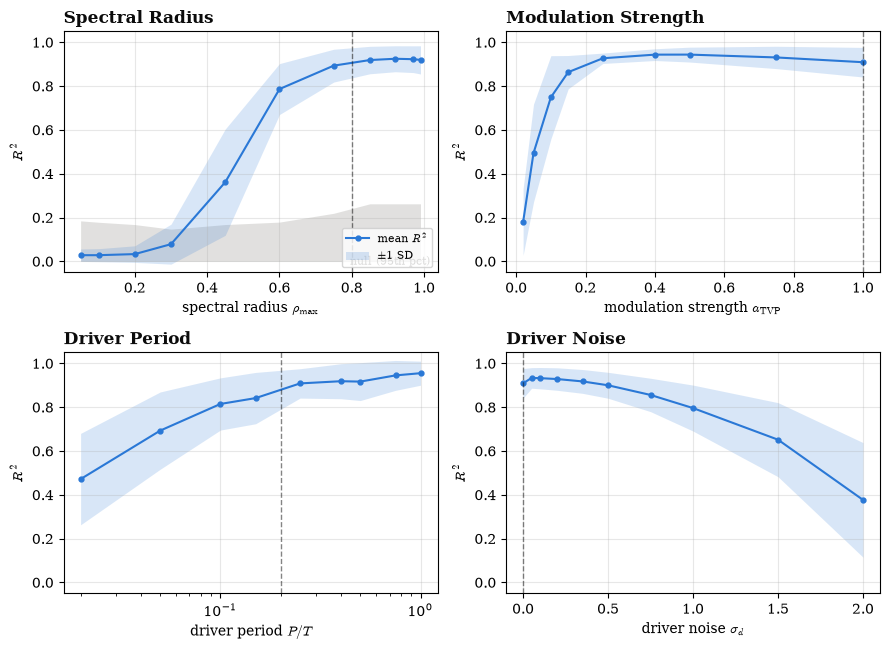

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(9.0, 6.6))

plot_sweep_gridstyle(df_rho, "rho_max", axes[0, 0], null=df_null_rho,
                     title="Spectral Radius",
                     xlabel=r"spectral radius $\rho_\mathrm{max}$",
                     canon_value=ACTIVE["rho_max"])
plot_sweep_gridstyle(df_amp, "tvp_amp", axes[0, 1],
                     title="Modulation Strength",
                     xlabel=r"modulation strength $a_\mathrm{TVP}$",
                     canon_value=ACTIVE["tvp_amp"])
plot_sweep_gridstyle(df_period, "P_over_T", axes[1, 0], logx=True,
                     title="Driver Period",
                     xlabel=r"driver period $P/T$",
                     canon_value=ACTIVE["tvp_period"] / ACTIVE["T"])
plot_sweep_gridstyle(df_noise, "tvp_noise_std", axes[1, 1],
                     title="Driver Noise",
                     xlabel=r"driver noise $\sigma_d$",
                     canon_value=ACTIVE["tvp_noise_std"])

for ax in axes.flat:
    ax.set_title(ax.get_title(), fontweight="bold")

axes[0, 0].legend(loc="lower right", fontsize=8)

fig.tight_layout()
save(fig, "panelE_sweeps_2x2")
